# 02. Baseline

**Модель:** логистическая регрессия + `class_weight=balanced` (дисбаланс классов)

In [1]:
import sys
from pathlib import Path

def _project_root() -> Path:
    here = Path.cwd().resolve()
    for i in [here, *here.parents]:
        if (i / 'src' / 'config.py').is_file():
            return i
    raise FileNotFoundError()

ROOT = _project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

try:
    import numpy as np
    import pandas as pd
    import matplotlib
    from sklearn.metrics import ConfusionMatrixDisplay, classification_report
    from sklearn.linear_model import LogisticRegression
except ModuleNotFoundError as e:
    raise ModuleNotFoundError()
from IPython import get_ipython
if get_ipython() is not None:
    get_ipython().run_line_magic('matplotlib', 'inline')
else:
    matplotlib.use('module://matplotlib_inline.backend_inline')

from src.config import RANDOM_STATE
from src.modeling import classification_metrics, make_baseline_logistic
from src.preprocessing import full_pipeline

np.random.seed(RANDOM_STATE)
enc = full_pipeline(with_engineering=False)
X_tr, X_va, X_te = enc.X_train, enc.X_val, enc.X_test
y_tr, y_va, y_te = enc.y_train, enc.y_val, enc.y_test
print('Train/val/test', X_tr.shape, X_va.shape, X_te.shape, 'pos rate', y_tr.mean().round(3))

Train/val/test (940, 51) (235, 51) (295, 51) pos rate 0.162


In [2]:
clf = make_baseline_logistic()
clf.fit(X_tr, y_tr)
proba_va = clf.predict_proba(X_va)[:, 1]
pred_va = clf.predict(X_va)
proba_te = clf.predict_proba(X_te)[:, 1]
pred_te = clf.predict(X_te)
print('Val:', classification_metrics(y_va, pred_va, proba_va))
print('Test:', classification_metrics(y_te, pred_te, proba_te))

Val: {'accuracy': 0.7702127659574468, 'precision': 0.3974358974358974, 'recall': 0.8157894736842105, 'f1': 0.5344827586206896, 'roc_auc': 0.8709591236975688}
Test: {'accuracy': 0.7694915254237288, 'precision': 0.3670886075949367, 'recall': 0.6170212765957447, 'f1': 0.4603174603174603, 'roc_auc': 0.7740219629375429}


In [3]:
print(classification_report(y_te, pred_te, target_names=['Stay', 'Attrition']))

              precision    recall  f1-score   support

        Stay       0.92      0.80      0.85       248
   Attrition       0.37      0.62      0.46        47

    accuracy                           0.77       295
   macro avg       0.64      0.71      0.66       295
weighted avg       0.83      0.77      0.79       295



Text(0.5, 1.0, 'Сonfusion matrix для baseline-модели (test)')

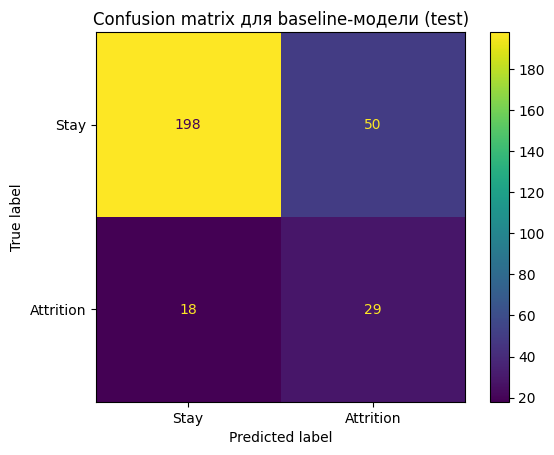

In [4]:
disp = ConfusionMatrixDisplay.from_predictions(y_te, pred_te, display_labels=['Stay', 'Attrition'])
disp.ax_.set_title('Сonfusion matrix для baseline-модели (test)')

- Baseline уже дает высокий `recall` по классу `Attrition=1` на validation
- На test качество падает по `ROC-AUC` и `F1`, значит модель будем использовать как точку отсчет, но не как финальный вариант
- Сравим её с ансамблями, тюнингом и PCA, чтобы улучшить баланс между качеством ранжирования и стабильностью на test